#Lab3  - Regresión Logistica


In [315]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [316]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

import pandas as pd

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

#Para separa el Dataset 20% y 80% para diferentes pruebas
from sklearn.model_selection import train_test_split

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

##Regresion Logistica

En esta parte del ejercicio, se creará un modelo que en base a las especifiaciones de un dispositivo movil lo clasifique si es barato o caro dependiendo de sus "especificaciones que presente", como ser: ram,  battery_power, n_cores, dual_sim, int_memory

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [317]:
data= pd.read_csv('/content/drive/MyDrive/sis420/machine_learning/datasets/train.csv')

In [318]:
data["price_range"] = np.where(data["price_range"] <= 1, 0, 1)

# Dividiendo los datos en conjuntos de entrenamiento y prueba
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Dividimos los datos para X_test y y_test donde seran los datos para el prueba
X_test = test_data.iloc[:, [0, 3, 6, 9, 13]]  # Todas las filas, solo esas columnas
y_test = test_data.iloc[:, 20]                # Todas las filas, columna 20

# Dividimos los datos para X_train y y_train para el entremamiento
X_train = train_data.iloc[:, [0, 3, 6, 9, 13]]
y_train = train_data.iloc[:, 20]

m = y_train.size

# Mostramos los datos que seran para el entrenamiento
print("Datos de X_train:")
print(X_train)
print("Datos de y_train:")
print(y_train)

# Mostramos la cantidad de ejemplos que tienen X_train y y_train
print('-' * 80)
print("El 80% de ejemplos que seran para el entrenamiento son: {:.0f}".format(len(train_data)))
print("El 20% de ejemplos que seran para el test son: {:.0f}".format(len(test_data)))

Datos de X_train:
      battery_power  dual_sim  int_memory  n_cores   ram
968            1923         1          46        1  1489
240             633         0          49        8  3560
819            1236         1          57        1  1406
692             781         0          38        5  3508
420            1456         1           7        5  1587
...             ...       ...         ...      ...   ...
1130           1975         1          31        1  3022
1294            589         0          59        8   362
860            1829         0          15        5  2080
1459           1927         1          11        8  2916
1126            635         1          50        5  2107

[1600 rows x 5 columns]
Datos de y_train:
968     0
240     1
819     0
692     1
420     0
       ..
1130    1
1294    0
860     1
1459    1
1126    0
Name: price_range, Length: 1600, dtype: int64
--------------------------------------------------------------------------------
El 80% de ejemplos

Función de normalización de datos

---



In [319]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)

    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

Normalizamos los datos

---



La normalización es necesaria porque las variables pueden tener escalas diferentes, y esto afecta la eficiencia del algoritmo de gradiente descendente.
Se lleva a cabo un escalamiento que centra los datos en torno a valores más manejables, facilitando la convergencia del modelo

In [320]:
X_norm, mu, sigma = featureNormalize(X_train)

In [321]:
X_norm

,battery_power,dual_sim,int_memory,n_cores,ram
968,1.548360,0.970437,0.754832,-1.547446,-0.580476
240,-1.379535,-1.030464,0.919763,1.510316,1.336453
819,-0.010914,0.970437,1.359577,-1.547446,-0.657302
692,-1.043621,-1.030464,0.315017,0.199847,1.288322
420,0.488416,0.970437,-1.389265,0.199847,-0.489767
...,...,...,...,...,...
1130,1.666383,0.970437,-0.069821,-1.547446,0.838477
1294,-1.479401,-1.030464,1.469531,1.510316,-1.623634
860,1.335009,-1.030464,-0.949450,0.199847,-0.033443
1459,1.557438,0.970437,-1.169357,1.510316,0.740363


Agregamos una columna de 1

In [322]:
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [323]:
X_ready

array([[ 1.        ,  1.54835969,  0.97043679,  0.75483201, -1.54744588,
        -0.58047631],
       [ 1.        , -1.3795348 , -1.03046381,  0.91976253,  1.51031591,
         1.33645326],
       [ 1.        , -0.01091435,  0.97043679,  1.35957724, -1.54744588,
        -0.65730159],
       ...,
       [ 1.        ,  1.33500924, -1.03046381, -0.94945002,  0.19984657,
        -0.03344329],
       [ 1.        ,  1.55743843,  0.97043679, -1.16935738,  1.51031591,
         0.74036314],
       [ 1.        , -1.37499543,  0.97043679,  0.97473937,  0.19984657,
        -0.00845194]])

###Implementacion

####Fución Sigmoidea

---
$$ h_\theta(x) = g(\theta^T x)$$
$$g(z) = \frac{1}{1+e^{-z}}$$

La función sigmoidea o tambien llamada función de logistica, nos permite calcaluar o predecir una probabilidad de un hecho que de 0 a 1. Donde z es la transpuesta de theta por X, que es nuestra hipótesis.

In [324]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con `z=0`, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de `z`.

In [325]:
# Prueba la implementacion de la funcion sigmoid
print(sigmoid(0))

0.5


In [326]:
# Prueba la implementación de la funcion sigmoidea
z = [0, 0.5, 1]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [0, 0.5, 1] ) =  [0.5        0.62245933 0.73105858]


###Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X

Función de costo: mide qué tan bien se ajusta el modelo a los datos


---


Gradiente descendente: actualiza los parámetros (theta) en cada iteración para minimizar la función de costo

---



In [327]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [328]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [329]:
from matplotlib import pyplot

theta calculado por el descenso por el gradiente: [ 0.01014552  0.96268461 -0.085237   -0.05936142  0.11938385  3.7881026 ]


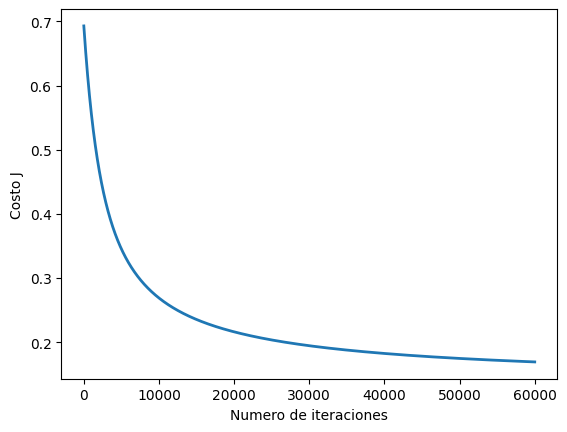

In [305]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 60000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(6)
theta, J_history = descensoGradiente(theta, X_ready, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [306]:
print(f"Con un costo de: { J_history[-1]} ")

Con un costo de: 0.16919836305528754 


###Test de validación

---

para verificar si el modelo es capaz de predecir correctamente


In [307]:
# Normalizamos el X_test
X_test_norm = (X_test - mu) / sigma
m_test = len(X_test)

X_test_norm

,battery_power,dual_sim,int_memory,n_cores,ram
1860,0.919657,-1.030464,-0.399682,-1.110623,-1.323738
353,-0.133477,-1.030464,-1.334288,1.510316,0.413624
1333,1.659574,-1.030464,-1.004427,1.073493,-0.740606
905,-0.571527,-1.030464,-0.839496,-0.673800,1.643754
1289,-1.420389,0.970437,1.414554,0.199847,-0.194499
...,...,...,...,...,...
965,0.313651,0.970437,-0.729543,1.510316,1.662266
1284,-0.566987,-1.030464,-1.114381,0.199847,-0.094533
1739,-0.446694,-1.030464,-1.114381,0.636670,-0.298167
261,-1.163915,0.970437,-0.399682,-0.236977,-0.071393


In [308]:
X_test_ready = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)
print(X_test_ready)

[[ 1.          0.91965677 -1.03046381 -0.39968162 -1.11062276 -1.32373775]
 [ 1.         -0.13347738 -1.03046381 -1.3342879   1.51031591  0.4136243 ]
 [ 1.          1.65957429 -1.03046381 -1.00442686  1.0734928  -0.74060611]
 ...
 [ 1.         -0.446694   -1.03046381 -1.11438054  0.63666969 -0.29816655]
 [ 1.         -1.16391466  0.97043679 -0.39968162 -0.23697654 -0.07139313]
 [ 1.         -0.12666832 -1.03046381 -0.06982059  1.51031591  0.30625403]]


In [309]:
# inicializamos nuestra y_predicha donde almacenaremos nuestras y predichas
y_predicha = []

# calculamos la Y predicha de cada fila de X_test_ready
for i in X_test_ready:
  y_predicha.append(sigmoid(np.dot(i, theta)))

y_predicha = np.array(y_predicha)

y_umbral = (y_predicha >= 0.5).astype(int)

In [310]:
# Convertimos los datos de prediccion a un Dataframe
df_pred = pd.DataFrame(y_predicha*100, columns = ['Probabilidad de celular caro %'])
df_pred['Probabilidad de celular caro %'] = df_pred['Probabilidad de celular caro %'].abs()

In [311]:
pd.set_option('display.max_columns', None)

In [312]:
X_columans = ['ram','battery_power','n_cores','dual_sim','int_memory']
X_test = np.array(X_test)
X_test = pd.DataFrame(X_test, columns = X_columans)

y_test = np.array(y_test)
y_test = pd.DataFrame(y_test, columns = ['Valores del Y Reales'])

df_resultado = pd.concat([ y_test, df_pred, X_test], axis = 1)
df_resultado.head(200)

,Valores del Y Reales,Probabilidad de celular caro %,ram,battery_power,n_cores,dual_sim,int_memory
0,0,1.567328,1646,0,25,2,686
1,1,85.764257,1182,0,8,8,2563
2,0,28.453341,1972,0,14,7,1316
3,1,99.680791,989,0,17,3,3892
4,0,9.648973,615,1,58,5,1906
...,...,...,...,...,...,...,...
195,0,47.857044,1986,1,51,8,1614
196,0,1.843779,1510,1,47,2,887
197,0,7.253235,1068,0,52,8,1436
198,0,66.697077,986,0,23,8,2385


###Precisión de mi modelo de regresión logistica:

---
verificación con los datos de train en base a test


In [313]:
y_umbral = (y_predicha >= 0.5).astype(int)


In [314]:
# Mostramos la precisión de entrenamiento
print("Precisión de entrenamiento: {:.2f} % ".format(np.mean(y_umbral == y_test.values.ravel()) * 100))

Precisión de entrenamiento: 94.25 % 
